In [1]:
import torch
print(torch.__version__)
print(torch.tensor([1.0, 2.0]).sum())

2.12.0+cpu
tensor(3.)


In [2]:
import sdv
print(sdv.__version__)
from sdv.single_table import GaussianCopulaSynthesizer
print("import OK")

1.14.0
import OK


In [3]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
from augmentation.synthesizer import GaussianCopulaSynthesizer

# Tiny fake dataframe — just enough to test fit() without loading real data
fake_df = pd.DataFrame({
    "hour":        np.tile(np.arange(24), 7),         # one week, 168 rows
    "day_of_week": np.repeat(np.arange(7), 24),
    "is_weekend":  np.repeat([0,0,0,0,0,1,1], 24),
    "is_holiday":  np.zeros(168, dtype=int),
    "sessions":    np.random.poisson(lam=1.5, size=168)  # realistic sparse demand
})

synth = GaussianCopulaSynthesizer()
synth.fit(fake_df)
result = synth.sample(n_rows=48, real_df=fake_df)
print(result.shape)
print(result.head(10))

C:\Users\rksan_amz5yv3\ev-coldstart-forecast\venv\Lib\site-packages\sdv\single_table\base.py:84: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


GaussianCopulaSynthesizer fitted on 168 rows.
(48, 10)
   hour  day_of_week  is_weekend  is_holiday  lag_1h  lag_24h  lag_168h  \
0     0            0           0           0     0.0      0.0       0.0   
1     1            0           0           0     3.0      0.0       0.0   
2     2            0           0           0     1.0      0.0       0.0   
3     3            0           0           0     2.0      0.0       0.0   
4     4            0           0           0     1.0      0.0       0.0   
5     5            0           0           0     3.0      0.0       0.0   
6     6            0           0           0     2.0      0.0       0.0   
7     7            0           0           0     1.0      0.0       0.0   
8     8            0           0           0     2.0      0.0       0.0   
9     9            0           0           0     2.0      0.0       0.0   

   rolling_24h_mean  rolling_7d_mean  sessions  
0          3.000000         3.000000         3  
1          2.000000  

In [4]:
import sys
sys.path.insert(0, '../src/models')
sys.path.insert(0, '../src/augmentation')
sys.path.insert(0, '../src/evaluation')

import pandas as pd
import numpy as np
import mlflow
import mlflow.lightgbm
from pathlib import Path

from global_model import load_model, FEATURE_COLS, TARGET_COL, SITE_MAP, PROCESSED_DIR
from transfer import fine_tune, predict, temporal_split
from metrics import mae
from synthesizer import GaussianCopulaSynthesizer

mlflow.set_tracking_uri("http://localhost:5000")
EXPERIMENT_NAME = "phase4_augmentation"
mlflow.set_experiment(EXPERIMENT_NAME)

MODEL_PATH = Path('../models/global_model.pkl')
OFFICE_DIR = PROCESSED_DIR
WEEKS = [1, 2, 3]
TARGET_SYNTHETIC_WEEKS = 6  # how many weeks equivalent we augment up to
HOURS_PER_WEEK = 168

print("Imports OK")

Imports OK


In [5]:
# Load the pre-trained global model from disk
# We do NOT retrain it here — it was trained and saved in phase3_transfer.ipynb
global_booster = load_model(MODEL_PATH)
print("Global model loaded.")

# Find all office001 parquet files
office_files = sorted(PROCESSED_DIR.glob('office001_*.parquet'))
print(f"Found {len(office_files)} office001 stations:")
for f in office_files:
    print(f"  {f.name}")

Global model loaded.
Found 8 office001 stations:
  office001_19-102-260-1633.parquet
  office001_19-102-260-1634.parquet
  office001_19-102-260-1635.parquet
  office001_19-102-260-1636.parquet
  office001_19-102-260-1637.parquet
  office001_19-102-260-1638.parquet
  office001_19-102-260-1639.parquet
  office001_19-102-260-1640.parquet


In [6]:
def prepare_synthetic_rows(synthetic_df: pd.DataFrame, 
                            real_df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds site_encoded and month to synthetic rows so the feature
    matrix matches what the global LightGBM model expects.

    site_encoded: always 2 (office001)
    month: mode of month in real fine-tuning data — month ranked
           3rd last in feature importance so this approximation
           has negligible effect on predictions.
    """
    df = synthetic_df.copy()
    
    df['site_encoded'] = SITE_MAP['office001']  # always 2
    df['month'] = real_df['month'].mode()[0]    # most common month in real data
    
    # Verify all expected feature columns are present
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Synthetic df missing columns: {missing}")
    
    return df[FEATURE_COLS + [TARGET_COL]]

In [7]:
for office_file in office_files:
    df = pd.read_parquet(office_file)
    print(f"{office_file.stem}: {len(df)} rows ({len(df)/168:.1f} weeks)")

office001_19-102-260-1633: 13610 rows (81.0 weeks)
office001_19-102-260-1634: 14048 rows (83.6 weeks)
office001_19-102-260-1635: 14498 rows (86.3 weeks)
office001_19-102-260-1636: 12753 rows (75.9 weeks)
office001_19-102-260-1637: 10253 rows (61.0 weeks)
office001_19-102-260-1638: 8170 rows (48.6 weeks)
office001_19-102-260-1639: 15054 rows (89.6 weeks)
office001_19-102-260-1640: 15416 rows (91.8 weeks)


In [8]:
import inspect
from transfer import temporal_split
print(inspect.getsource(temporal_split))

def temporal_split(df, train_weeks):
    """
    Split a station's data chronologically.
    First train_weeks of data → fine-tuning set.
    Everything after → evaluation set.
    Never shuffles.
    """
    start = df['timestamp'].min()
    cutoff = start + pd.Timedelta(weeks=train_weeks)
    train = df[df['timestamp'] < cutoff].copy()
    test  = df[df['timestamp'] >= cutoff].copy()
    return train, test



In [11]:
results = []

for office_file in office_files:
    station_id = office_file.stem

    df = pd.read_parquet(office_file)
    df = df.sort_values('timestamp').reset_index(drop=True)
    df['site_encoded'] = SITE_MAP['office001']

    for weeks in WEEKS:
        n_finetune_rows = weeks * HOURS_PER_WEEK
        finetune_df, test_df = temporal_split(df, weeks)

        if len(finetune_df) < HOURS_PER_WEEK or len(test_df) < HOURS_PER_WEEK:
            print(f"  Skipping {station_id} @ {weeks}w — insufficient data")
            continue

        # ── NO AUGMENTATION ──
        booster_base = fine_tune(global_booster, finetune_df)
        preds_base   = predict(booster_base, test_df)
        mae_base     = mae(test_df[TARGET_COL].values, preds_base)

        # ── GAUSSIAN COPULA ──
        n_synthetic = max(0, (TARGET_SYNTHETIC_WEEKS * HOURS_PER_WEEK) - n_finetune_rows)

        if n_synthetic > 0:
            synth = GaussianCopulaSynthesizer()
            synth.fit(finetune_df)
            synthetic_rows = synth.sample(n_rows=n_synthetic, real_df=finetune_df)
            synthetic_rows = prepare_synthetic_rows(synthetic_rows, finetune_df)
            augmented_df = pd.concat(
                [synthetic_rows, finetune_df[FEATURE_COLS + [TARGET_COL]]],
                ignore_index=True
            )
        else:
            augmented_df = finetune_df[FEATURE_COLS + [TARGET_COL]]

        booster_gc = fine_tune(global_booster, augmented_df)
        preds_gc   = predict(booster_gc, test_df)
        mae_gc     = mae(test_df[TARGET_COL].values, preds_gc)

        print(f"{station_id} | {weeks}w | base: {mae_base:.4f} | GC: {mae_gc:.4f}")

        results.append({
            'station_id':  station_id,
            'weeks':       weeks,
            'mae_base':    mae_base,
            'mae_gc':      mae_gc,
            'n_synthetic': n_synthetic,
        })

        # ── LOG TO MLFLOW ──
        with mlflow.start_run(run_name=f"{station_id}_{weeks}w_gc"):
            mlflow.log_params({
                'station_id':             station_id,
                'finetune_weeks':         weeks,
                'augmentation':           'gaussian_copula',
                'n_real_rows':            len(finetune_df),
                'n_synthetic_rows':       n_synthetic,
                'target_synthetic_weeks': TARGET_SYNTHETIC_WEEKS,
            })
            mlflow.log_metrics({
                'mae_no_augmentation': mae_base,
                'mae_gc_augmentation': mae_gc,
                'mae_delta':           mae_gc - mae_base,
            })

print("\nAblation complete.")

C:\Users\rksan_amz5yv3\ev-coldstart-forecast\venv\Lib\site-packages\sdv\single_table\base.py:84: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


GaussianCopulaSynthesizer fitted on 168 rows.
office001_19-102-260-1633 | 1w | base: 0.0352 | GC: 0.0602


C:\Users\rksan_amz5yv3\ev-coldstart-forecast\venv\Lib\site-packages\sdv\single_table\base.py:84: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


GaussianCopulaSynthesizer fitted on 336 rows.
office001_19-102-260-1633 | 2w | base: 0.0350 | GC: 0.0543


C:\Users\rksan_amz5yv3\ev-coldstart-forecast\venv\Lib\site-packages\sdv\single_table\base.py:84: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


...

GaussianCopulaSynthesizer fitted on 168 rows.
office001_19-102-260-1640 | 1w | base: 0.0442 | GC: 0.0780


C:\Users\rksan_amz5yv3\ev-coldstart-forecast\venv\Lib\site-packages\sdv\single_table\base.py:84: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


GaussianCopulaSynthesizer fitted on 336 rows.
office001_19-102-260-1640 | 2w | base: 0.0440 | GC: 0.0657


C:\Users\rksan_amz5yv3\ev-coldstart-forecast\venv\Lib\site-packages\sdv\single_table\base.py:84: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


GaussianCopulaSynthesizer fitted on 504 rows.
office001_19-102-260-1640 | 3w | base: 0.0428 | GC: 0.0564

Ablation complete.


In [12]:
results_df = pd.DataFrame(results)

# Average across all 8 office001 stations per data volume
summary = (
    results_df
    .groupby('weeks')[['mae_base', 'mae_gc']]
    .mean()
    .round(4)
)
summary['delta'] = (summary['mae_gc'] - summary['mae_base']).round(4)
summary['helped'] = summary['delta'] < 0

print("Phase 4 Augmentation Results (averaged across office001 stations)")
print("=" * 60)
print(summary.to_string())
print()
print("delta < 0 means augmentation helped (lower MAE is better)")

Phase 4 Augmentation Results (averaged across office001 stations)
       mae_base  mae_gc   delta  helped
weeks                                  
1        0.0277  0.0484  0.0207   False
2        0.0281  0.0405  0.0124   False
3        0.0278  0.0321  0.0043   False

delta < 0 means augmentation helped (lower MAE is better)


C:\Users\rksan_amz5yv3\ev-coldstart-forecast\venv\Lib\site-packages\sdv\single_table\base.py:84: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


GaussianCopulaSynthesizer fitted on 13610 rows.


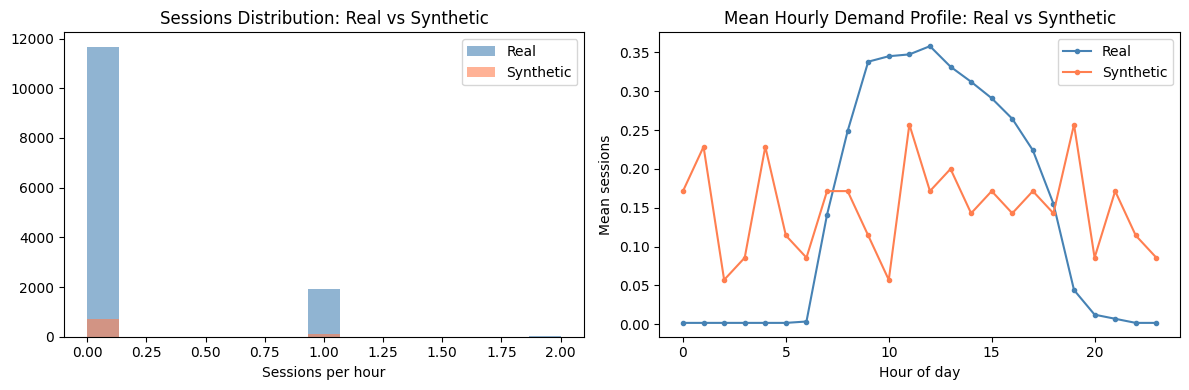

Quality check plot saved.


In [13]:
import matplotlib.pyplot as plt

# Pick one station, one week, inspect synthetic vs real sessions distribution
sample_file = office_files[0]
sample_df   = pd.read_parquet(sample_file).sort_values('timestamp').reset_index(drop=True)
sample_df['site_encoded'] = SITE_MAP['office001']

finetune_sample, _ = temporal_split(sample_df, HOURS_PER_WEEK)

synth_check = GaussianCopulaSynthesizer()
synth_check.fit(finetune_sample)
synthetic_check = synth_check.sample(n_rows=HOURS_PER_WEEK * 5, real_df=finetune_sample)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sessions distribution comparison
axes[0].hist(finetune_sample['sessions'], bins=15, alpha=0.6, 
             label='Real', color='steelblue')
axes[0].hist(synthetic_check['sessions'], bins=15, alpha=0.6, 
             label='Synthetic', color='coral')
axes[0].set_title('Sessions Distribution: Real vs Synthetic')
axes[0].set_xlabel('Sessions per hour')
axes[0].legend()

# Hourly demand profile comparison
real_hourly    = finetune_sample.groupby('hour')['sessions'].mean()
synth_hourly   = synthetic_check.groupby('hour')['sessions'].mean()
axes[1].plot(real_hourly.index,  real_hourly.values,  
             label='Real', color='steelblue', marker='o', markersize=3)
axes[1].plot(synth_hourly.index, synth_hourly.values, 
             label='Synthetic', color='coral',     marker='o', markersize=3)
axes[1].set_title('Mean Hourly Demand Profile: Real vs Synthetic')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Mean sessions')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/phase4_synthetic_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Quality check plot saved.")

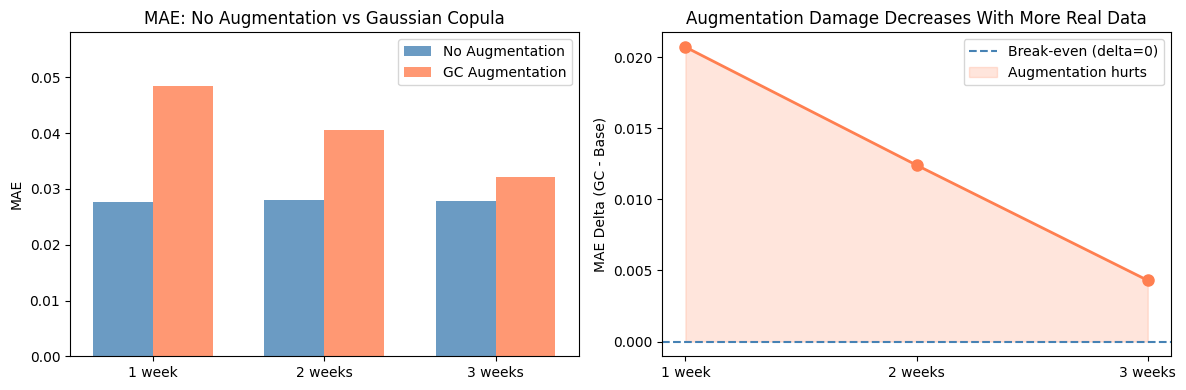

Results plot saved.


In [14]:
import matplotlib.pyplot as plt

weeks_list  = summary.index.tolist()
mae_base    = summary['mae_base'].tolist()
mae_gc      = summary['mae_gc'].tolist()
delta       = summary['delta'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left — MAE comparison bar chart
x = np.arange(len(weeks_list))
width = 0.35
axes[0].bar(x - width/2, mae_base, width, label='No Augmentation',
            color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, mae_gc,   width, label='GC Augmentation',
            color='coral', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{w} week{"s" if w > 1 else ""}' for w in weeks_list])
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE: No Augmentation vs Gaussian Copula')
axes[0].legend()
axes[0].set_ylim(0, max(mae_gc) * 1.2)

# Right — delta trend (how much augmentation hurts vs data volume)
axes[1].plot(weeks_list, delta, marker='o', color='coral',
             linewidth=2, markersize=8)
axes[1].axhline(y=0, color='steelblue', linestyle='--',
                linewidth=1.5, label='Break-even (delta=0)')
axes[1].fill_between(weeks_list, delta, 0,
                     where=[d > 0 for d in delta],
                     color='coral', alpha=0.2, label='Augmentation hurts')
axes[1].set_xticks(weeks_list)
axes[1].set_xticklabels([f'{w} week{"s" if w > 1 else ""}' for w in weeks_list])
axes[1].set_ylabel('MAE Delta (GC - Base)')
axes[1].set_title('Augmentation Damage Decreases With More Real Data')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/phase4_augmentation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results plot saved.")

In [6]:
# Check what columns actually exist in a caltech file
import pandas as pd
import glob

caltech_files = glob.glob('../data/processed/caltech_*.parquet')
df = pd.read_parquet(caltech_files[0])
print("Columns:", list(df.columns))
print("'site' column unique values:", df['site'].unique())

Columns: ['timestamp', 'station_id', 'site', 'sessions', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_24h_mean', 'rolling_7d_mean']
'site' column unique values: ['caltech']


In [8]:
import os

# Check model exists
model_path = '../models/global_model.pkl'
print("Model exists:", os.path.exists(model_path))

# Check what features it was trained on
import pickle
with open(model_path, 'rb') as f:
    booster = pickle.load(f)

print("Feature names:", booster.feature_name())

Model exists: True
Feature names: ['hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_24h_mean', 'rolling_7d_mean', 'site_encoded']
